# BMR(기초대사량) 예측 모델 분석

이 노트북에서는 BMR 데이터셋을 분석하고 예측 모델을 만듭니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

# 한글 폰트 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 데이터 로드
df = pd.read_csv('../data/BMR_Dataset.csv')
print('데이터 shape:', df.shape)
df.head()

데이터 shape: (9000, 6)


,user_id,age,weight,height,gender,BMR
0,1243,27.0,73.066833,162.723887,Male,1576.878448
1,4971,28.0,77.730284,179.495414,Female,1536.656455
2,1629,57.0,85.704790,158.403053,Male,1697.694955
3,6201,47.0,67.012186,168.113746,Male,1471.524942
4,7833,36.0,79.929512,175.561126,Male,1743.147435


In [3]:
# 기본 통계량 확인
df.describe()

,user_id,age,weight,height,BMR
count,9000.000000,8989.000000,8993.000000,8992.000000,9000.000000
mean,4500.500000,40.967293,69.624393,169.908044,1475.479479
std,2598.220545,13.588124,15.036687,9.894197,200.373795
min,1.000000,18.000000,11.484503,133.816706,690.711745
25%,2250.750000,29.000000,59.509476,163.323677,1340.847649
50%,4500.500000,41.000000,69.680270,169.893600,1475.039499
75%,6750.250000,53.000000,79.614839,176.620686,1610.698220
max,9000.000000,64.000000,124.454472,204.366568,2209.519518


In [4]:
# 결측치 확인
print('\n결측치 개수:')
print(df.isnull().sum())


결측치 개수:
user_id     0
age        11
weight      7
height      8
gender     10
BMR         0
dtype: int64


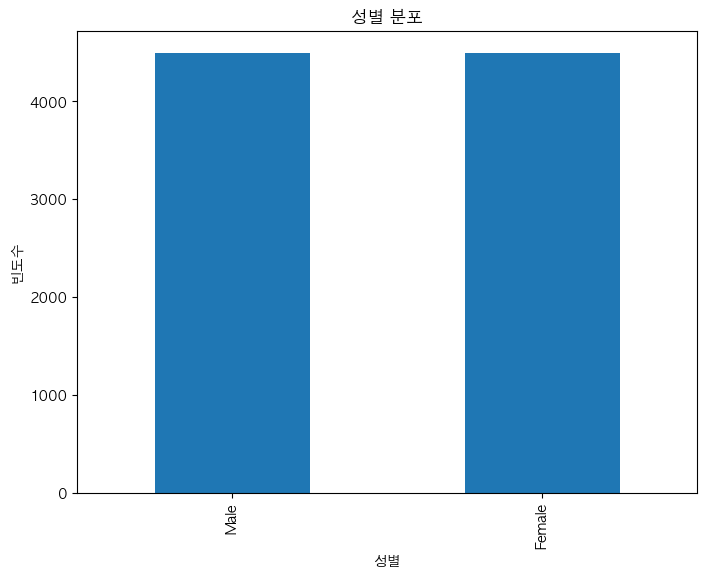

In [5]:
# 성별 분포 확인
plt.figure(figsize=(8, 6))
df['gender'].value_counts().plot(kind='bar')
plt.title('성별 분포')
plt.xlabel('성별')
plt.ylabel('빈도수')
plt.show()

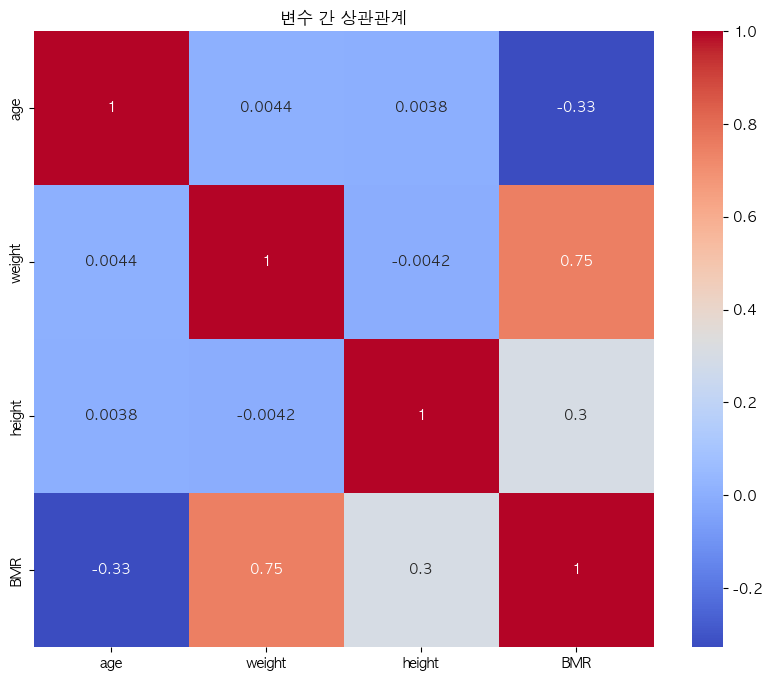

In [6]:
# 상관관계 분석
numeric_cols = ['age', 'weight', 'height', 'BMR']
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('변수 간 상관관계')
plt.show()

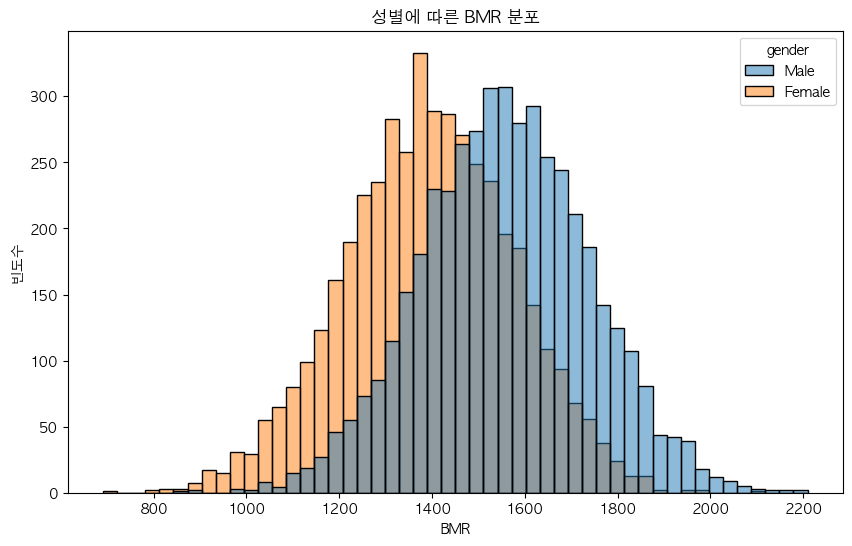

In [7]:
# BMR 분포
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='BMR', hue='gender', bins=50)
plt.title('성별에 따른 BMR 분포')
plt.xlabel('BMR')
plt.ylabel('빈도수')
plt.show()

In [9]:
# 데이터 전처리
# 성별을 숫자로 변환
le = LabelEncoder()
df['gender_encoded'] = le.fit_transform(df['gender'])

# 특성과 타겟 분리
X = df[['age', 'weight', 'height', 'gender_encoded']]
y = df['BMR']

# 학습/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 특성 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# Random Forest 모델 학습
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# 예측
y_pred = rf_model.predict(X_test_scaled)

# 모델 성능 평가
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.2f}')
print(f'R2 Score: {r2:.4f}')

RMSE: 56.22
R2 Score: 0.9204


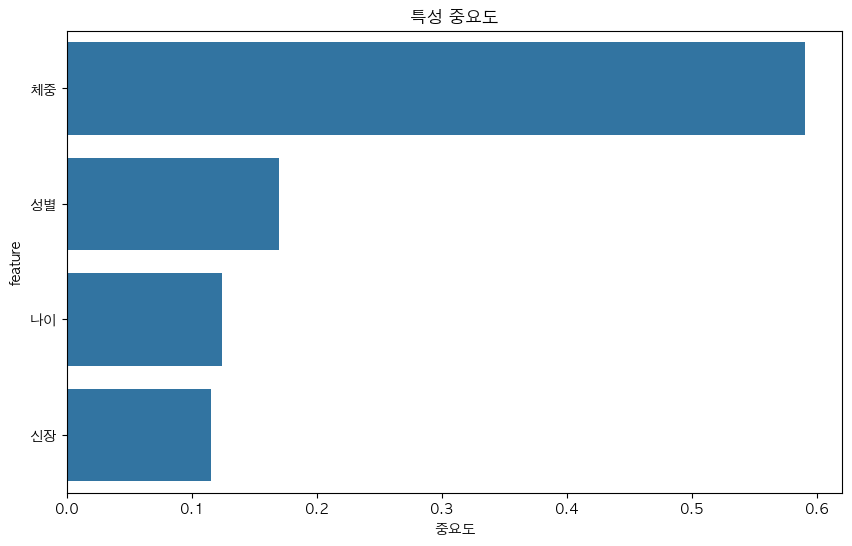

In [11]:
# 특성 중요도 시각화
feature_importance = pd.DataFrame({
    'feature': ['나이', '체중', '신장', '성별'],
    'importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('특성 중요도')
plt.xlabel('중요도')
plt.show()

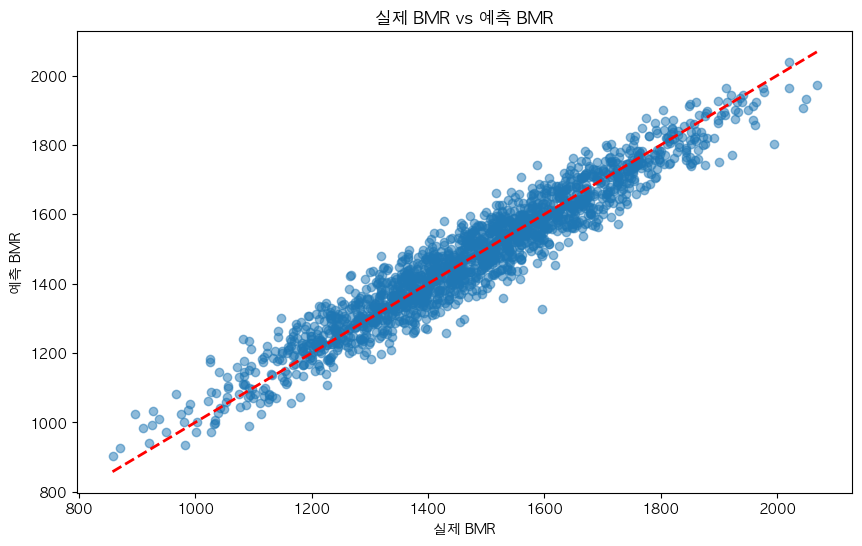

In [12]:
# 실제값과 예측값 비교
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('실제 BMR')
plt.ylabel('예측 BMR')
plt.title('실제 BMR vs 예측 BMR')
plt.show()

In [13]:
# 모델 저장
import joblib
import os

# models 디렉토리가 없으면 생성
if not os.path.exists('../models'):
    os.makedirs('../models')

# 모델 저장
model_path = '../models/bmr_rf_model.joblib'
scaler_path = '../models/bmr_scaler.joblib'

# Random Forest 모델 저장
joblib.dump(rf_model, model_path)
# Scaler 저장
joblib.dump(scaler, scaler_path)

print(f'모델이 저장되었습니다: {model_path}')
print(f'Scaler가 저장되었습니다: {scaler_path}')

모델이 저장되었습니다: ../models/bmr_rf_model.joblib
Scaler가 저장되었습니다: ../models/bmr_scaler.joblib
